## 3.1 Loss function calculation
$$
L = \sum_{i=1}^n(y_i- mx_i-b)^2\\
\frac{\delta(L)}{\delta(b)} = \sum2(y_i-mx_i-b)(-1)\\
0 = -(\sum(y_i)+m*\sum(x_i)-\sum(b))\\
L = \sum_{i=1}^n(y_i- mx_i-\bar{y}-m\bar{x})^2+ \lambda*m^2\\
\frac{\delta(L)}{\delta(m)}=2\sum_{i=1}^n(y_i- mx_i-\bar{y}+m\bar{x})(-x_i+\bar{x})+2\lambda m\\
\lambda m - \sum_{i=1}^{n}[(y_i-\bar{y})-m(x_i-\bar{x})](x_i-\bar{x})=0\\
m = \frac{\sum_{i=1}^{n}(y_i-\bar{y})(x_i-\bar{x})}{\sum_{i=1}^{n}(x_i-\bar{y})^2+\lambda}\\
\text{as the value of }\lambda \text{will increase the m will decrease}
$$

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np


In [2]:
X,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=42)

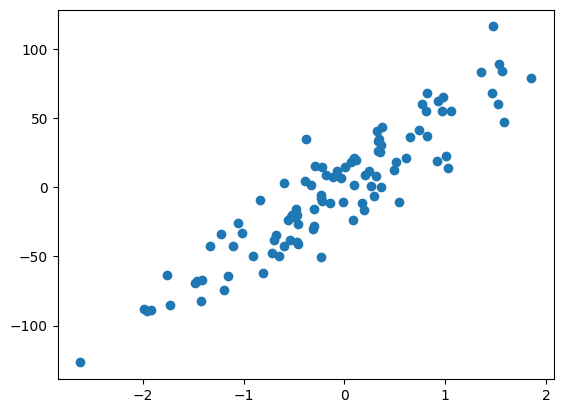

In [3]:
plt.scatter(X,y)

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[47.13323967]
2.3302306410539453


In [6]:
from sklearn.linear_model import Ridge
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[41.9906212]
1.7961876226164746


In [ ]:
class meraRidge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.m=None
        self.b=None
        self.coef_=None
        self.intercept_=None
    def fit(self,X_train,y_train):
        # we have the slope wrt to b and m both
        num=0
        den=0
        X_train= self.X_train
        y_train= self.y_train
        for i in range(X_train.shape[0]):
            num+=(y_train[i]-y_train.mean())*(X_train[i]-X_train.mean())
            den+=(y_train[i]-y_train.mean())**2
            self.m = num/(den+self.alpha)
            self.b =y_train.mean()-(self.m*X_train.mean())
        self.coef_=self.m
        self.intercept_ = self.b
    def predict(self,X_test):
        return np.dot(X_test,self.m)+self.b


        


### Rigid Regression for nD data

# Ridge Regression for n-Dimensional Data

## Dataset Representation

Let:

$$
X=
\begin{bmatrix}
x_{11} & x_{12} & \cdots & x_{1n}\\
x_{21} & x_{22} & \cdots & x_{2n}\\
\vdots & \vdots & \ddots & \vdots\\
x_{m1} & x_{m2} & \cdots & x_{mn}
\end{bmatrix}
$$

where:

- $m$ = number of training examples
- $n$ = number of features

Weight vector:

$$
W=
\begin{bmatrix}
w_1\\
w_2\\
\vdots\\
w_n
\end{bmatrix}
$$

Target vector:

$$
Y=
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_m
\end{bmatrix}
$$

## Prediction

For a single training example:

$$
\hat{y}
=
w_0+w_1x_1+w_2x_2+\cdots+w_nx_n
$$

Matrix form:

$$
\hat{Y}=XW+w_0
$$

## Mean of Target Variable

$$
\bar{y}
=
\frac{1}{m}\sum_{i=1}^{m}y_i
$$

## Ridge Regression Cost Function

$$
L
=
\frac{1}{m}
\sum_{i=1}^{m}
(y_i-\hat{y}_i)^2
+
\lambda
\sum_{j=1}^{n}
w_j^2
$$

where:

- $\lambda$ is the regularization parameter.
- Larger $\lambda$ results in stronger regularization.
- The bias term $w_0$ is typically not regularized.

## Ridge Regression Gradient

For weight $w_j$:

$$
\frac{\partial L}{\partial w_j}
=
\frac{\partial MSE}{\partial w_j}
+
2\lambda w_j
$$

Gradient Descent Update:

$$
w_j
=
w_j
-
\alpha
\left(
\frac{\partial MSE}{\partial w_j}
+
2\lambda w_j
\right)
$$

where:

- $\alpha$ is the learning rate.
- The term $2\lambda w_j$ continuously shrinks the weights toward zero.

$$
\textbf{In case of normal regression}\\
L=\sum_{i=1}^{n}(y_i-\hat{y_i})^2\\
L =\sum_{i=1}^{n}(XW-Y)^T(XW-Y)
$$

$$
L=\sum_{i=1}^{n}(y_i-\hat{y_i})^2+\lambda ||W^2|| \\
L =\sum_{i=1}^{n}(XW-Y)^T(XW-Y) + \lambda W^TW
$$
$$
L = \left[(Xw)^T - y^T\right](Xw-y) + \lambda w^T w
$$

$$
= (w^T X^T - y^T)(Xw-y) + \lambda w^T w
$$

$$
= w^T X^T X w
- w^T X^T y
- y^T X w
+ y^T y
+ \lambda w^T w
$$

Since

$$
w^T X^T y = (y^T X w)^T
$$
and both are scalars,
$$
w^T X^T y = y^T X w
$$

Therefore,

$$
L = w^T X^T X w
- 2w^T X^T y
+ y^T y
+ \lambda w^T w

$$

#### From the  derivation of

$$
\frac{dL}{dW}=2X^TXW-2X^TY+0+2\lambda W
$$

$$
W = (X^TX+\lambda I)^\text{-1}X^TY
$$

### Code

In [8]:
from sklearn.datasets import load_diabetes
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split



In [9]:
X,y = load_diabetes(return_X_y=True)

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [31]:
from sklearn.linear_model import Ridge
reg1 = Ridge(alpha=0.1)
reg1.fit(X_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [32]:
out = reg1.predict(X_test)

In [38]:
print(reg1.coef_)

[  39.6635292  -213.84688049  505.91429153  341.71447431 -108.80630119
  -70.57580966 -211.90657957  160.19354049  332.77354206   77.68045166]


In [33]:
print()

In [34]:
type(out)

numpy.ndarray

In [35]:
y_test.shape

(133,)

In [36]:
out.shape

(133,)

In [37]:
from sklearn.metrics import r2_score
res = r2_score(y_test,out)
print(res)

0.48031838456367215


In [27]:
class MeraRidge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.intercept_=None
        self.coeff_=None
    def fit(self,X_train,y_train):
        self.X_train=X_train
        self.y_train=y_train
        X_train=np.insert(self.X_train,0,1,axis=1)
        I= np.identity(X_train.shape[1])
        result= np.linalg.inv(np.dot(X_train.T,X_train)+self.alpha*I).dot(X_train.T).dot(y_train)
        self.intercept_= result[0]
        self.coeff_ = result[1:]
    def predict(self,X_test):
        return np.dot(X_test,self.coeff_)+self.intercept_
   
        

In [29]:
reg = MeraRidge()
reg.fit(X_train, y_train)
res = reg.predict(X_test)
from sklearn.metrics import r2_score
print(r2_score(y_test,res))


0.4802561896539246


In [39]:
print(reg1.coef_)

[  39.6635292  -213.84688049  505.91429153  341.71447431 -108.80630119
  -70.57580966 -211.90657957  160.19354049  332.77354206   77.68045166]


In [30]:
print(reg.coeff_)

[  39.66828821 -213.8419192   505.957649    341.70560555 -108.792473
  -70.5884286  -211.88959636  160.1973241   332.77576891   77.7254541 ]


## There is some difference in the values of the coefficents because the inbuild Ridge Regression the 0,0 of the identity matrix is 0 as they dont want to affect the the Intercept

In [42]:
class MeraRidgeOriginal:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.intercept_=None
        self.coeff_=None
    def fit(self,X_train,y_train):
        self.X_train=X_train
        self.y_train=y_train
        X_train=np.insert(self.X_train,0,1,axis=1)
        I= np.identity(X_train.shape[1])
        I[0][0]=0
        result= np.linalg.inv(np.dot(X_train.T,X_train)+self.alpha*I).dot(X_train.T).dot(y_train)
        self.intercept_= result[0]
        self.coeff_ = result[1:]
    def predict(self,X_test):
        return np.dot(X_test,self.coeff_)+self.intercept_
   
        

In [43]:
reg3 = MeraRidgeOriginal()

In [44]:
reg3.fit(X_train,y_train)

In [45]:
print(reg3.coeff_)

[  39.6635292  -213.84688049  505.91429153  341.71447431 -108.80630119
  -70.57580966 -211.90657957  160.19354049  332.77354206   77.68045166]


In [46]:
print(reg1.coef_)

[  39.6635292  -213.84688049  505.91429153  341.71447431 -108.80630119
  -70.57580966 -211.90657957  160.19354049  332.77354206   77.68045166]
